# Phân Tích Khám Phá Dữ Liệu (EDA) - Kinh Tế Việt Nam
## Dự án: Chuyển dịch cơ cấu kinh tế và Đóng góp của TFP
---
Notebook này thực hiện trực quan hóa chi tiết các bộ dữ liệu về GDP, Cơ cấu ngành và TFP nhằm tìm kiếm các insight sâu sắc về động lực tăng trưởng của Việt Nam.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình font tiếng Việt và style
plt.rcParams['font.family'] = 'Arial' # Hoặc font hỗ trợ tiếng Việt trên hệ thống
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

### 1. Load dữ liệu đã xử lý

In [5]:
df_gdp_usage = pd.read_csv('../data/processed/gdp_usage_processed.csv', index_col=0)
df_gdp_sectors = pd.read_csv('../data/processed/gdp_sectors_processed.csv', index_col=0)
df_tfp = pd.read_csv('../data/processed/tfp_contribution_processed.csv', index_col=0)

print("Dữ liệu đã sẵn sàng!")
df_gdp_usage

Dữ liệu đã sẵn sàng!


,GDP_TongSo,TongTaiSanCoDinh,ThayDoiTonKho,TieuDungCuoiCung,TieuDungNhaNuoc,TieuDungHoDanCu,ChanLechXuatNhapKhau,SaiSo
Nam,,,,,,,,
1995,228892.0,58187.0,3944.0,187233.0,18741.0,168492.0,-20819.0,347.0
1996,272036.0,71597.0,4853.0,225231.0,22722.0,202509.0,-29839.0,194.0
1997,313623.0,83734.0,5020.0,250584.0,25500.0,225084.0,-25526.0,-189.0
1998,361016.0,97551.0,7324.0,283444.0,27523.0,255921.0,-26371.0,-932.0
1999,399942.0,102799.0,7704.0,301690.0,27137.0,274553.0,-11418.0,-833.0
2000,441646.0,122101.0,8670.0,321853.0,28346.0,293507.0,-10878.0,-100.0
2001,481295.0,140301.0,9732.0,342607.0,30463.0,312144.0,-10982.0,-363.0
2002,535762.0,166828.0,11155.0,382137.0,33390.0,348747.0,-27684.0,3326.0
2003,613443.0,204608.0,12826.0,445221.0,38770.0,406451.0,-51288.0,2076.0


### 2. Phân tích Chuyển dịch Cơ cấu Ngành
Trực quan hóa sự thay đổi tỷ trọng giữa Nông nghiệp (I), Công nghiệp (II) và Dịch vụ (III).

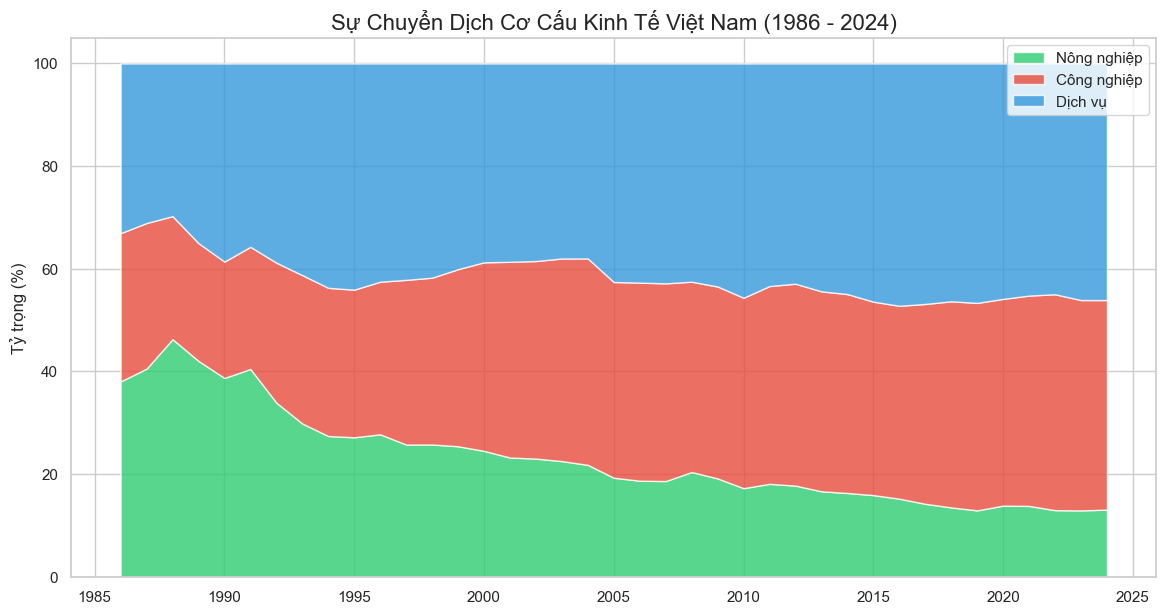

In [3]:
# Tính tỷ trọng cơ cấu
df_percent = df_gdp_sectors.copy()
cols_val = ['Giá trị: Nông lâm thủy sản', 'Giá trị: Công nghiệp xây dựng', 'Giá trị: Dịch vụ']
total = df_percent[cols_val].sum(axis=1)

for col in cols_val:
    df_percent[col + ' (%)'] = (df_percent[col] / total) * 100

pct_cols = [c + ' (%)' for c in cols_val]

plt.figure(figsize=(14, 7))
plt.stackplot(df_percent.index, 
              df_percent[pct_cols[0]], 
              df_percent[pct_cols[1]], 
              df_percent[pct_cols[2]], 
              labels=['Nông nghiệp', 'Công nghiệp', 'Dịch vụ'],
              colors=['#2ecc71', '#e74c3c', '#3498db'], alpha=0.8)
plt.title('Sự Chuyển Dịch Cơ Cấu Kinh Tế Việt Nam (1986 - 2024)')
plt.ylabel('Tỷ trọng (%)')
plt.legend(loc='upper right')
plt.show()

### 3. Phân tích Động lực Tăng trưởng (GDP Usage)
Xem xét đóng góp của Tiêu dùng, Đầu tư và Xuất khẩu ròng.

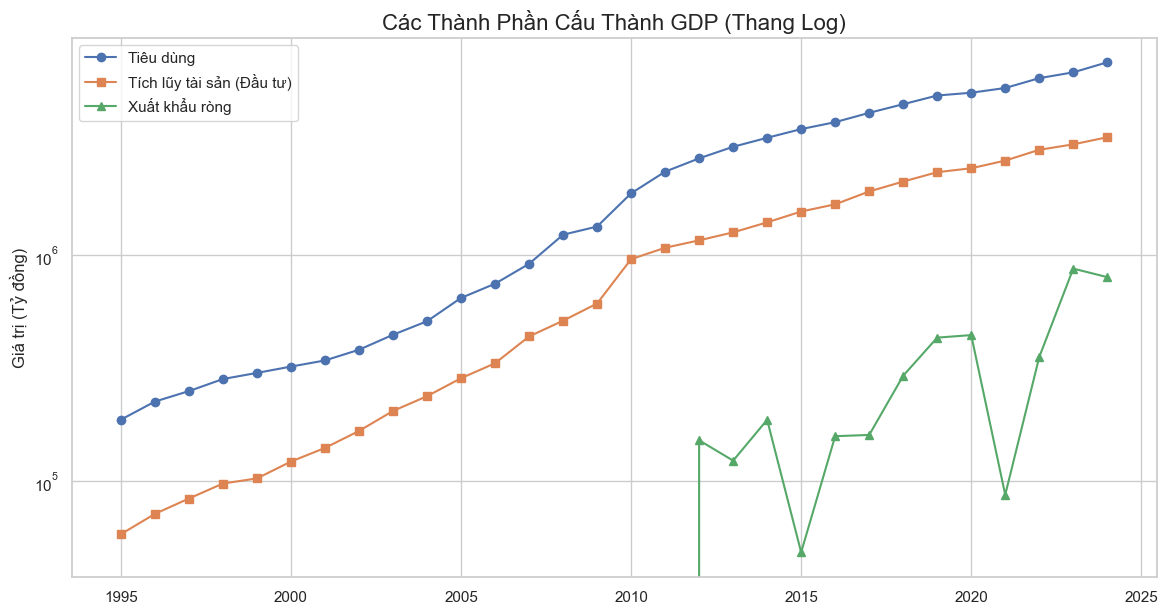

In [6]:
plt.figure(figsize=(14, 7))
plt.plot(df_gdp_usage.index, df_gdp_usage['TieuDungCuoiCung'], label='Tiêu dùng', marker='o')
plt.plot(df_gdp_usage.index, df_gdp_usage['TongTaiSanCoDinh'], label='Tích lũy tài sản (Đầu tư)', marker='s')
plt.plot(df_gdp_usage.index, df_gdp_usage['ChanLechXuatNhapKhau'], label='Xuất khẩu ròng', marker='^')
plt.yscale('log') # Dùng log scale vì giá trị tăng trưởng rất lớn qua các năm
plt.title('Các Thành Phần Cấu Thành GDP (Thang Log)')
plt.ylabel('Giá trị (Tỷ đồng)')
plt.legend()
plt.show()

### 4. Phân tích Hiệu quả Tăng trưởng (TFP Contribution)
Insight về việc tăng trưởng dựa trên vốn/lao động hay công nghệ (TFP).

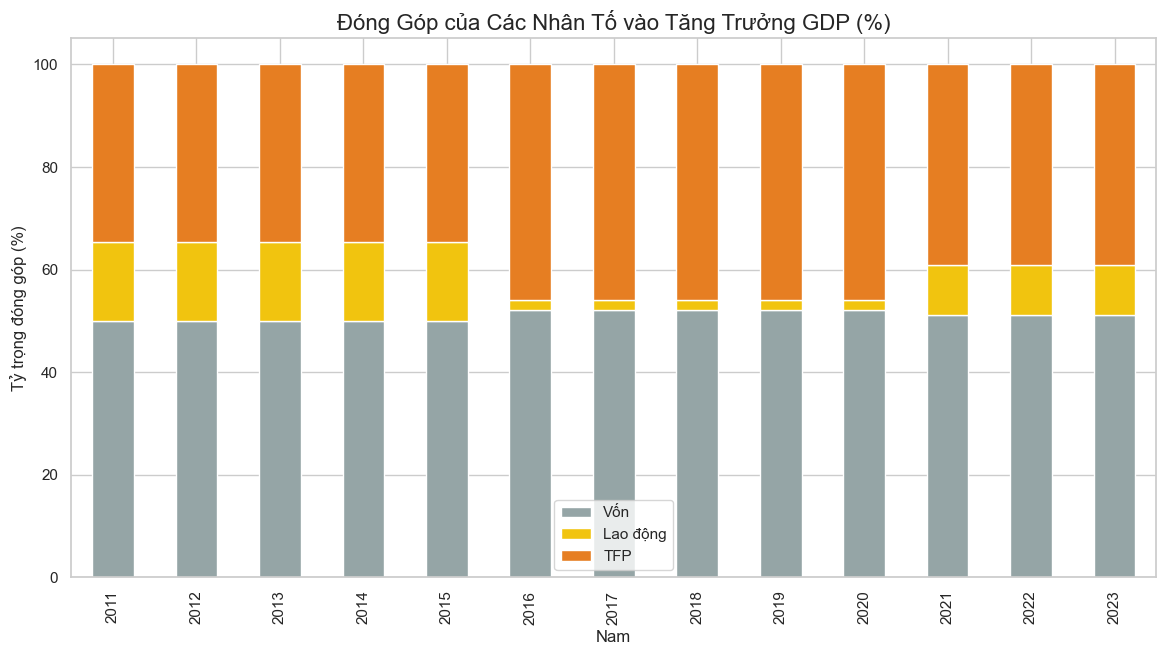

In [7]:
avg_tfp = df_tfp.groupby(df_tfp.index // 5 * 5).mean() # Nhóm theo chu kỳ 5 năm
ax = df_tfp[['Von_pct', 'LaoDong_pct', 'TFP_pct']].plot(kind='bar', stacked=True, figsize=(14, 7), color=['#95a5a6', '#f1c40f', '#e67e22'])
plt.title('Đóng Góp của Các Nhân Tố vào Tăng Trưởng GDP (%)')
plt.ylabel('Tỷ trọng đóng góp (%)')
plt.legend(['Vốn', 'Lao động', 'TFP'])
plt.show()

# EXECUTIVE DASHBOARD: TỔNG QUAN KINH TẾ VIỆT NAM
### Một cái nhìn toàn cảnh - Không cần giải thích thêm

C:\Users\QUI\AppData\Local\Temp\ipykernel_26652\1496729082.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


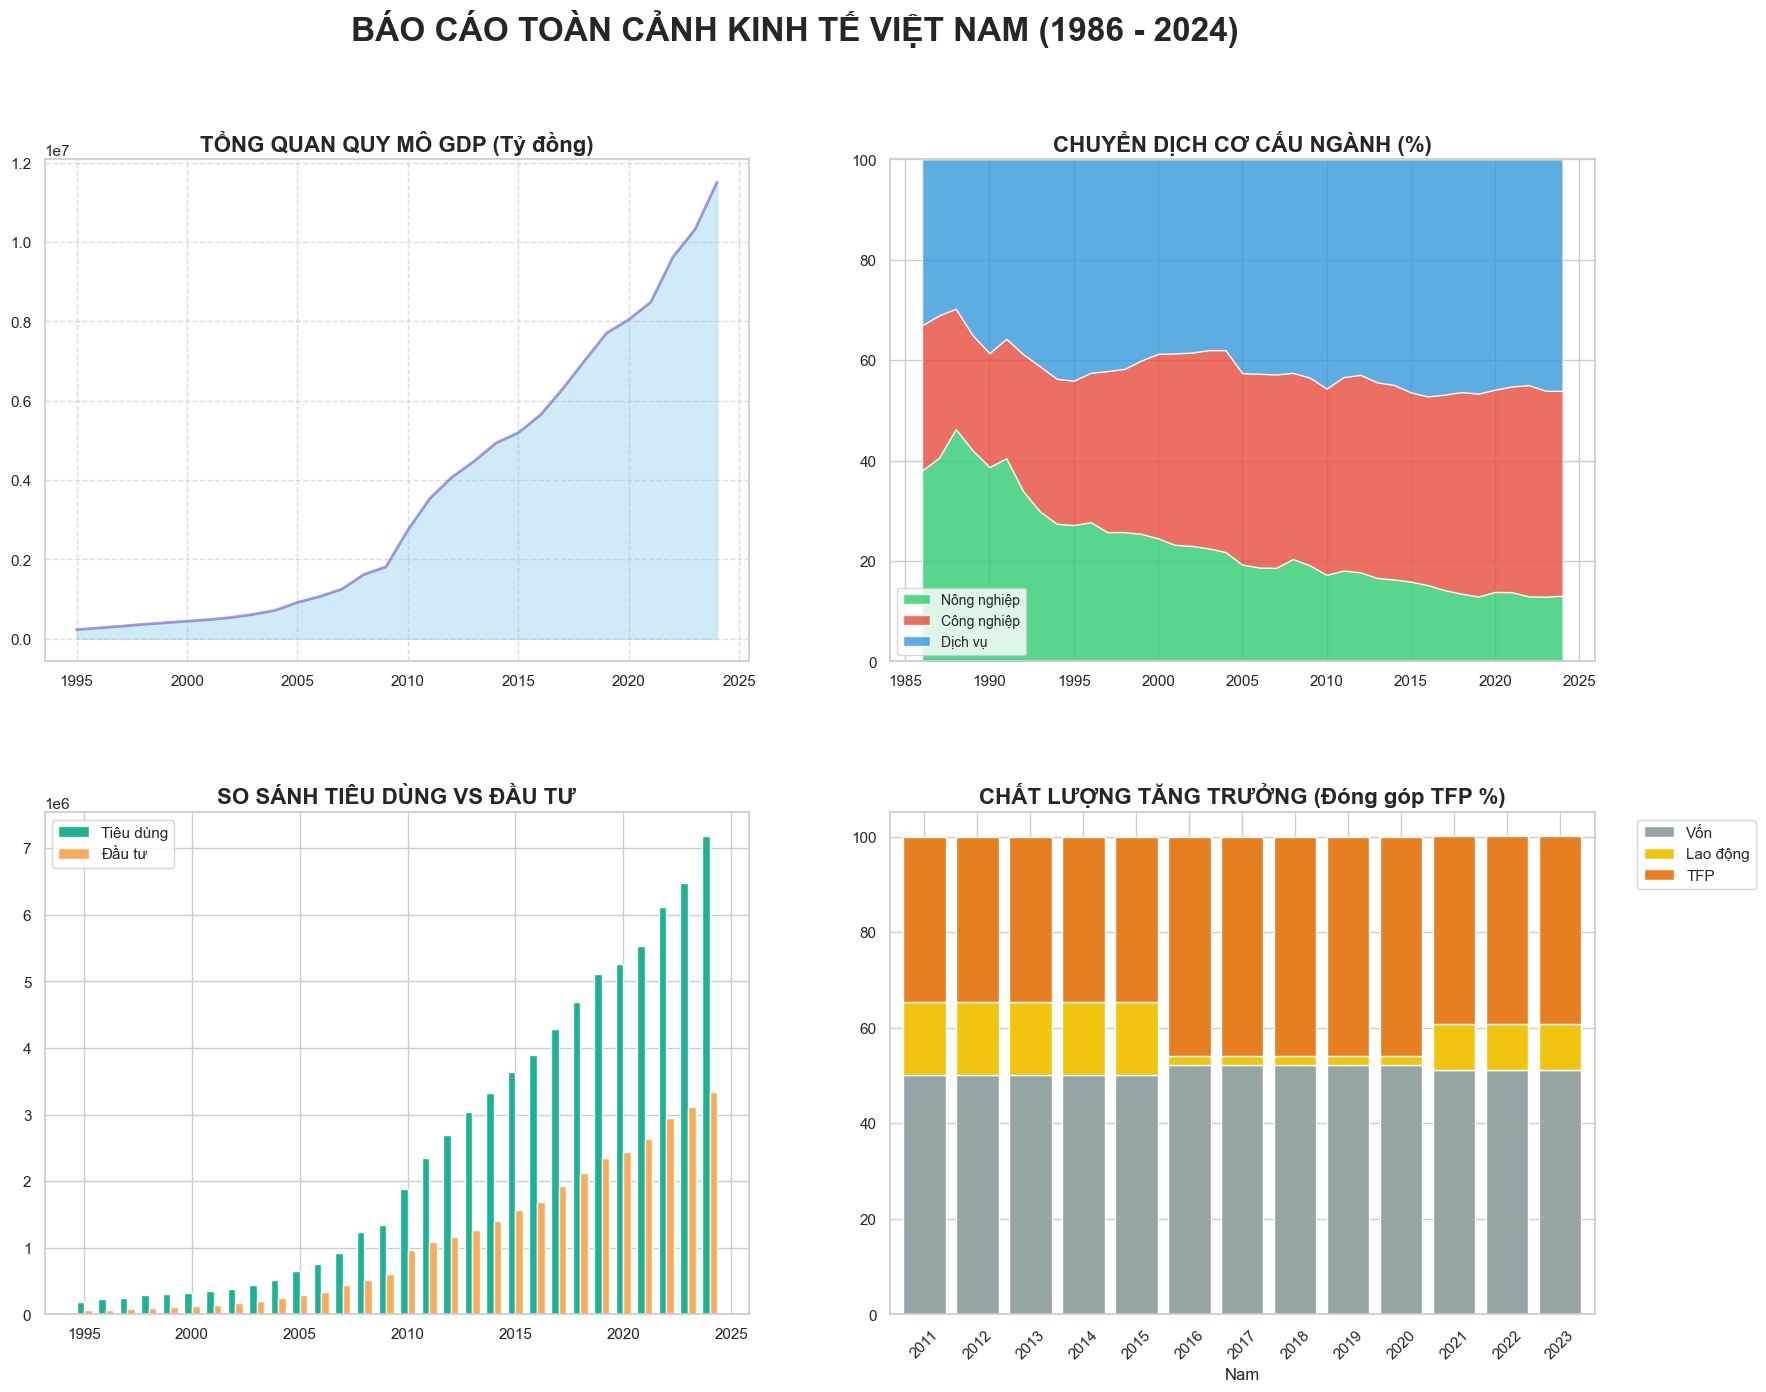

In [9]:
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# 1. Xu hướng GDP Tổng thể
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(df_gdp_usage.index, df_gdp_usage['GDP_TongSo'], color='skyblue', alpha=0.4)
ax1.plot(df_gdp_usage.index, df_gdp_usage['GDP_TongSo'], color='Slateblue', alpha=0.6, linewidth=2)
ax1.set_title('TỔNG QUAN QUY MÔ GDP (Tỷ đồng)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Cơ cấu Kinh tế (Structural Shift)
ax2 = fig.add_subplot(gs[0, 1])
ax2.stackplot(df_percent.index, 
              df_percent[pct_cols[0]], 
              df_percent[pct_cols[1]], 
              df_percent[pct_cols[2]], 
              labels=['Nông nghiệp', 'Công nghiệp', 'Dịch vụ'],
              colors=['#2ecc71', '#e74c3c', '#3498db'], alpha=0.8)
ax2.set_title('CHUYỂN DỊCH CƠ CẤU NGÀNH (%)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='lower left', fontsize=10)

# 3. Cân bằng Thương mại & Tiêu dùng
ax3 = fig.add_subplot(gs[1, 0])
bar_width = 0.35
ax3.bar(df_gdp_usage.index - bar_width/2, df_gdp_usage['TieuDungCuoiCung'], bar_width, label='Tiêu dùng', color='#1ab394')
ax3.bar(df_gdp_usage.index + bar_width/2, df_gdp_usage['TongTaiSanCoDinh'], bar_width, label='Đầu tư', color='#f8ac59')
ax3.set_title('SO SÁNH TIÊU DÙNG VS ĐẦU TƯ', fontweight='bold')
ax3.legend()

# 4. Đóng góp TFP (Growth Quality)
ax4 = fig.add_subplot(gs[1, 1])
df_tfp[['Von_pct', 'LaoDong_pct', 'TFP_pct']].plot(kind='bar', stacked=True, ax=ax4, color=['#95a5a6', '#f1c40f', '#e67e22'], width=0.8)
ax4.set_title('CHẤT LƯỢNG TĂNG TRƯỞNG (Đóng góp TFP %)', fontweight='bold')
ax4.set_xticklabels(df_tfp.index, rotation=45)
ax4.legend(['Vốn', 'Lao động', 'TFP'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('BÁO CÁO TOÀN CẢNH KINH TẾ VIỆT NAM (1986 - 2024)', fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()